In [1]:
import matplotlib.pyplot as plt
import numpy as np

def plot_convergence(sw_history, pol_history, window=50):
    # Calcul des moyennes mobiles pour lisser le "bruit" du RL
    sw_smoothed = np.convolve(sw_history, np.ones(window)/window, mode='valid')
    pol_smoothed = np.convolve(pol_history, np.ones(window)/window, mode='valid')

    plt.figure(figsize=(14, 5))

    # Plot Social Welfare
    plt.subplot(1, 2, 1)
    plt.plot(sw_history, alpha=0.3, color='blue', label='Brut')
    plt.plot(sw_smoothed, color='darkblue', linewidth=2, label=f'Moyenne ({window})')
    plt.title("Évolution du Social Welfare ($SW$)")
    plt.xlabel("Épisodes")
    plt.ylabel("Score SW")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Plot Pollution
    plt.subplot(1, 2, 2)
    plt.plot(pol_history, alpha=0.3, color='red', label='Brut')
    plt.plot(pol_smoothed, color='darkred', linewidth=2, label=f'Moyenne ({window})')
    plt.title("Stock de Pollution Final")
    plt.xlabel("Épisodes")
    plt.ylabel("Niveau de Pollution")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [2]:
import seaborn as sns

def plot_firm_strategy(firm_agent, firm_name="Firme"):
    # On sépare les états de type Taxe (0)
    tax_states = sorted([s for s in firm_agent.q_table.keys() if s[0] == 0])
    
    if not tax_states:
        print("Pas assez de données dans la Q-table pour afficher la heatmap.")
        return

    # On construit la matrice : Lignes = Taxes, Colonnes = Quantités q
    q_matrix = np.array([firm_agent.q_table[s] for s in tax_states])
    tax_values = [s[1] for s in tax_states]
    q_values = np.round(firm_agent.actions, 1)

    plt.figure(figsize=(10, 6))
    sns.heatmap(q_matrix, annot=False, cmap="viridis", 
                yticklabels=tax_values, xticklabels=q_values)
    plt.title(f"Cerveau de la {firm_name} (États de Taxe)")
    plt.ylabel("Valeur de la Taxe imposée par l'État")
    plt.xlabel("Quantité $q$ produite (Action choisie)")
    plt.show()

In [3]:
def plot_gov_decisions(gov_agent):
    # On récupère les états (pollution) connus par le gouvernement
    states = sorted(gov_agent.q_table.keys())
    best_actions = []
    
    for s in states:
        idx = np.argmax(gov_agent.q_table[s])
        a_type, a_val = gov_agent.actions[idx]
        best_actions.append((s * 5, a_type, a_val)) # s*5 pour revenir à la pollution réelle

    # On sépare pour le plot
    pollutions = [x[0] for x in best_actions]
    types = ["Taxe" if x[1] == 0 else "Quota" for x in best_actions]
    values = [x[2] for x in best_actions]

    plt.figure(figsize=(12, 5))
    
    # Scatter plot pour voir le type et la valeur
    colors = ['blue' if t == "Taxe" else 'orange' for t in types]
    plt.scatter(pollutions, values, c=colors, s=100, edgecolors='black', alpha=0.7)
    
    plt.title("Politique optimale choisie selon le niveau de Pollution")
    plt.xlabel("Niveau de Pollution")
    plt.ylabel("Valeur de la Politique (Taxe ou Quota)")
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # Légende custom
    from matplotlib.lines import Line2D
    legend_elements = [Line2D([0], [0], marker='o', color='w', label='Taxe', markerfacecolor='blue', markersize=10),
                       Line2D([0], [0], marker='o', color='w', label='Quota', markerfacecolor='orange', markersize=10)]
    plt.legend(handles=legend_elements)
    plt.show()

In [4]:
# --- INITIALISATION DES LISTES (Indispensable pour éviter le NameError) ---
history_sw = []
history_pol = []
# --- Initialisation ---
from env import EcoSystem
from agent import GovernmentAgent
from agent import  FirmAgent

env = EcoSystem(n_firms=5, price=15.0)
gov = GovernmentAgent()
firms = [FirmAgent() for _ in range(5)]


for ep in range(50000):
    state_vec = env.reset()
    pollution = state_vec[2]
    done = False
    ep_sw = 0 # Pour cumuler le bien-être social de l'épisode
    
    for step in range(20):
        gov_idx = gov.get_action(pollution)
        a_type, a_val = gov.actions[gov_idx]
        gov.decay_epsilon()
        q_indices, q_vals = [], []
        for f in firms:
            idx = f.get_action(a_type, a_val)
            q_indices.append(idx)
            q_vals.append(f.actions[idx])
            
        next_state_vec, reward_gov, rewards_firms = env.step_multi_firms(a_type, a_val, q_vals)
        next_pollution = next_state_vec[2]
        
        # Apprentissage...
        for i in range(5):
            firms[i].learn(a_type, a_val, q_indices[i], rewards_firms[i])
        gov.learn(pollution, gov_idx, reward_gov, next_pollution)
        
        pollution = next_pollution
        ep_sw += reward_gov # On cumule le SW du step
    
    # --- ENREGISTREMENT DES RÉSULTATS ---
    history_sw.append(ep_sw)        # On stocke le total du SW de l'épisode
    history_pol.append(pollution)   # On stocke la pollution finale de l'épisode
    
    for f in firms: f.decay_epsilon()
    if ep % 1000 == 0:
        print(f"Épisode {ep} terminé. Epsilon Gov: {gov.epsilon:.2f}")

Épisode 0 terminé. Epsilon Gov: 1.00
Épisode 1000 terminé. Epsilon Gov: 0.98
Épisode 2000 terminé. Epsilon Gov: 0.96
Épisode 3000 terminé. Epsilon Gov: 0.94
Épisode 4000 terminé. Epsilon Gov: 0.92
Épisode 5000 terminé. Epsilon Gov: 0.90
Épisode 6000 terminé. Epsilon Gov: 0.89
Épisode 7000 terminé. Epsilon Gov: 0.87
Épisode 8000 terminé. Epsilon Gov: 0.85
Épisode 9000 terminé. Epsilon Gov: 0.84
Épisode 10000 terminé. Epsilon Gov: 0.82
Épisode 11000 terminé. Epsilon Gov: 0.80
Épisode 12000 terminé. Epsilon Gov: 0.80
Épisode 13000 terminé. Epsilon Gov: 0.80
Épisode 14000 terminé. Epsilon Gov: 0.80
Épisode 15000 terminé. Epsilon Gov: 0.80
Épisode 16000 terminé. Epsilon Gov: 0.80
Épisode 17000 terminé. Epsilon Gov: 0.80
Épisode 18000 terminé. Epsilon Gov: 0.80
Épisode 19000 terminé. Epsilon Gov: 0.80
Épisode 20000 terminé. Epsilon Gov: 0.80
Épisode 21000 terminé. Epsilon Gov: 0.80
Épisode 22000 terminé. Epsilon Gov: 0.80
Épisode 23000 terminé. Epsilon Gov: 0.80
Épisode 24000 terminé. Epsilo

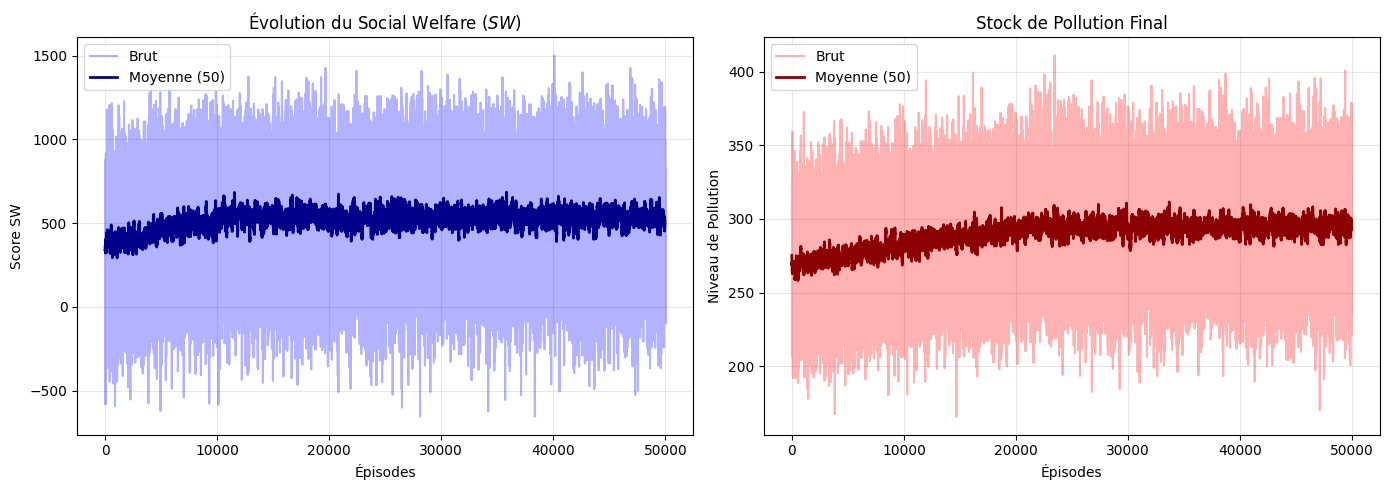

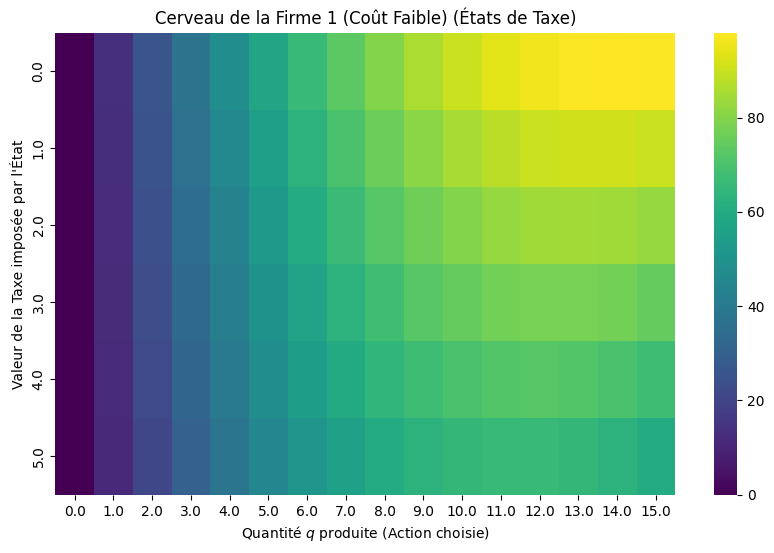

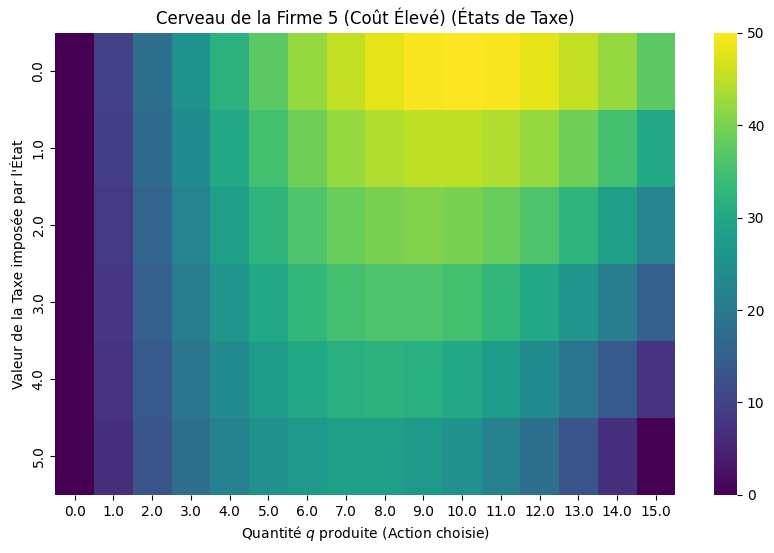

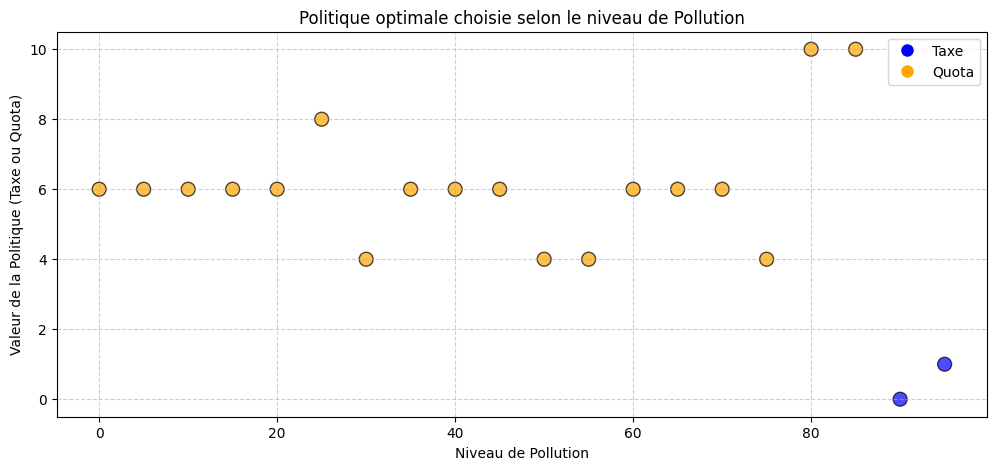

In [5]:
# 1. Voir si ça a convergé
plot_convergence(history_sw, history_pol)

# 2. Voir comment la Firme 1 (coût faible) et la Firme 5 (coût élevé) réagissent
plot_firm_strategy(firms[0], "Firme 1 (Coût Faible)")
plot_firm_strategy(firms[4], "Firme 5 (Coût Élevé)")

# 3. Voir ce que l'État a appris
plot_gov_decisions(gov)

In [6]:
def plot_policy_responses(firms_list):
    # Valeurs de politiques définies dans le Gouvernement
    tax_values = [0, 1, 2, 3, 4, 5]
    quota_values = [2, 4, 6, 8, 10]
    
    plt.figure(figsize=(15, 6))
    styles = ['-', '--', ':', '-.', (0, (3, 5, 1, 5))]

    # --- GRAPHIQUE 1 : RÉACTION À LA TAXE ---
    plt.subplot(1, 2, 1)
    for i, f in enumerate(firms_list):
        responses = []
        for v in tax_values:
            state_key = (0, float(v))
            if state_key in f.q_table:
                best_action_idx = np.argmax(f.q_table[state_key])
                responses.append(f.actions[best_action_idx])
            else:
                responses.append(None)
        
        plt.plot(tax_values, responses, marker='o', label=f"Firme {i+1} (a_i={1+i})")
    
    plt.title("Production apprise vs Niveau de Taxe")
    plt.xlabel("Valeur de la Taxe")
    plt.ylabel("Quantité produite $q$")
    plt.grid(True, alpha=0.3)
    plt.legend()

    # --- GRAPHIQUE 2 : RÉACTION AU QUOTA ---
    plt.subplot(1, 2, 2)
    for i, f in enumerate(firms_list):
        responses = []
        for v in quota_values:
            state_key = (1, float(v))
            if state_key in f.q_table:
                best_action_idx = np.argmax(f.q_table[state_key])
                responses.append(f.actions[best_action_idx])
            else:
                responses.append(None)
        
        plt.plot(quota_values, responses, marker='s', label=f"Firme {i+1}")

    plt.title("Production apprise vs Niveau de Quota")
    plt.xlabel("Valeur du Quota (Législatif)")
    plt.ylabel("Quantité produite $q$")
    plt.grid(True, alpha=0.3)
    plt.legend()

    plt.tight_layout()
    plt.show()

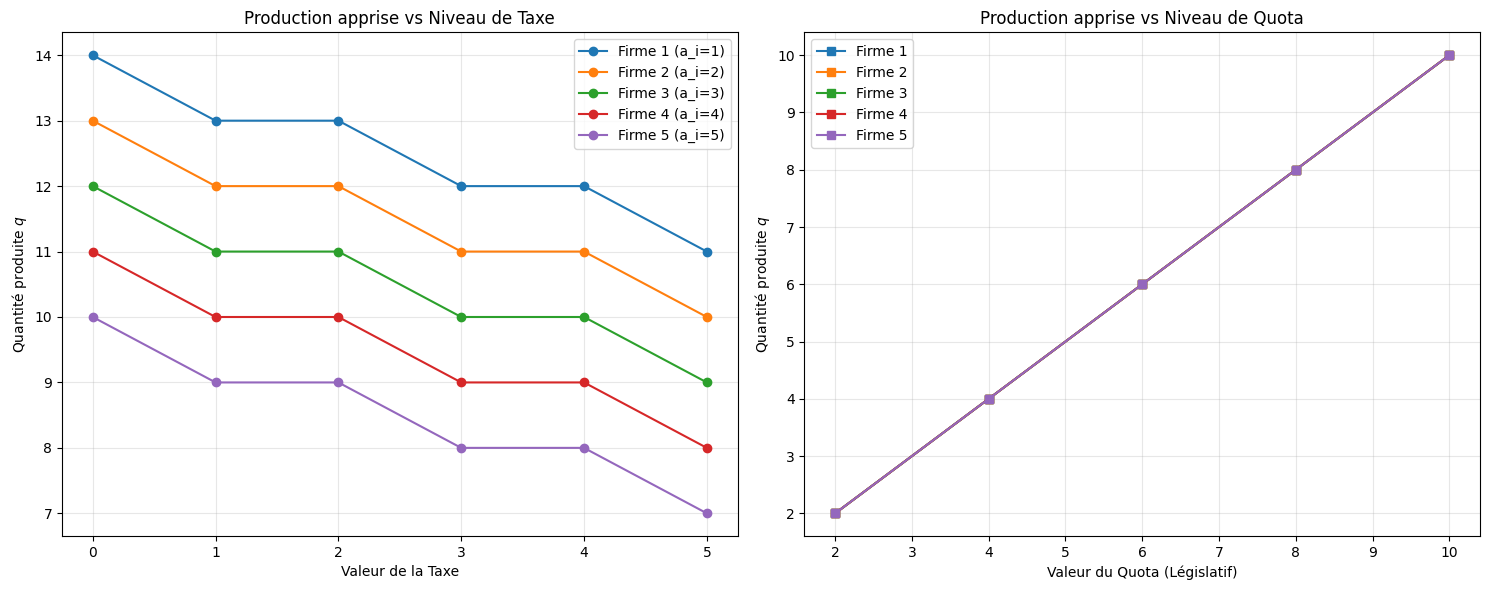

In [8]:
# Après l'entraînement :
plot_policy_responses(firms)